<a href="https://colab.research.google.com/github/riddhii24/MPI-Pesticide-Project/blob/main/mpis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Medicinal Plant Leaf Disease Dataset.zip'
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

print("Extracting... this will take a few minutes due to 7.5GB size")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done! Let's see what's inside:")
for item in os.listdir(extract_path):
    print(item)

Extracting... this will take a few minutes due to 7.5GB size
Done! Let's see what's inside:
Medicinal Plant Leaf Disease Dataset


In [6]:
dataset_root = '/content/dataset/Medicinal Plant Leaf Disease Dataset'

for item in os.listdir(dataset_root):
    print(item)


Medicinal_leaf_dataset.zip


In [7]:
import zipfile
import os

# find the zip inside
inner_zip = None
for item in os.listdir(dataset_root):
    if item.endswith('.zip'):
        inner_zip = os.path.join(dataset_root, item)
        print("Found:", inner_zip)

# extract it
extract_path2 = '/content/dataset/final'
os.makedirs(extract_path2, exist_ok=True)

print("Extracting inner zip...")
with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path2)

print("Done! Contents:")
for item in os.listdir(extract_path2):
    print(item)

Found: /content/dataset/Medicinal Plant Leaf Disease Dataset/Medicinal_leaf_dataset.zip
Extracting inner zip...
Done! Contents:
Medicinal_leaf_dataset


In [9]:
final_root = '/content/dataset/final/Medicinal_leaf_dataset'

print("Final folders:")
for item in sorted(os.listdir(final_root)):
    print(item)

Final folders:
Kalanchoe_Healthy
Kalanchoe_Web_Blight
Kalanchoe_Yellow
Kalanchoe_Yellow_Blight
Neem_Healthy
Neem_Spot
Neem_Web_Blight
Neem_Yellow
Tulsi_Downy_Mildew
Tulsi_Healthy
Tulsi_Web_Blight
Tulsi_Yellow_Spot


In [7]:
for folder in sorted(os.listdir(final_root)):
    folder_path = os.path.join(final_root, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")

Kalanchoe_Healthy: 209 images
Kalanchoe_Web_Blight: 213 images
Kalanchoe_Yellow: 204 images
Kalanchoe_Yellow_Blight: 213 images
Neem_Healthy: 244 images
Neem_Spot: 211 images
Neem_Web_Blight: 205 images
Neem_Yellow: 225 images
Tulsi_Downy_Mildew: 200 images
Tulsi_Healthy: 213 images
Tulsi_Web_Blight: 205 images
Tulsi_Yellow_Spot: 205 images


In [10]:
import shutil

# Define the grouping
class_map = {
    'Healthy': ['Kalanchoe_Healthy', 'Neem_Healthy', 'Tulsi_Healthy'],
    'Mild':    ['Neem_Spot', 'Kalanchoe_Yellow', 'Neem_Yellow',
                'Tulsi_Yellow_Spot', 'Tulsi_Downy_Mildew'],
    'Severe':  ['Kalanchoe_Web_Blight', 'Kalanchoe_Yellow_Blight',
                'Neem_Web_Blight', 'Tulsi_Web_Blight']
}

organized_path = '/content/dataset/organized'

for class_name, folders in class_map.items():
    class_dir = os.path.join(organized_path, class_name)
    os.makedirs(class_dir, exist_ok=True)

    for folder in folders:
        src = os.path.join(final_root, folder)
        for img in os.listdir(src):
            src_img = os.path.join(src, img)
            # rename to avoid duplicates across folders
            dst_img = os.path.join(class_dir, f"{folder}_{img}")
            shutil.copy(src_img, dst_img)

    print(f"{class_name}: {len(os.listdir(class_dir))} images")


Healthy: 666 images
Mild: 1045 images
Severe: 836 images


In [11]:
import random

split_path = '/content/drive/MyDrive/plant_dataset/split'
train_path = os.path.join(split_path, 'train')
val_path = os.path.join(split_path, 'val')
organized_path = '/content/dataset/organized'

random.seed(42)

for class_name in ['Healthy', 'Mild', 'Severe']:
    src = os.path.join(organized_path, class_name)
    images = os.listdir(src)
    random.shuffle(images)

    split_idx = int(0.8 * len(images))
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_path, class_name), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(src, img), os.path.join(train_path, class_name, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src, img), os.path.join(val_path, class_name, img))

    print(f"{class_name} → train: {len(train_imgs)}, val: {len(val_imgs)}")

print("Split dataset saved to Drive permanently!")

Healthy → train: 532, val: 134
Mild → train: 836, val: 209
Severe → train: 668, val: 168
Split dataset saved to Drive permanently!


In [10]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
```

This should print something like:
```
TensorFlow version: 2.x.x
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

SyntaxError: invalid decimal literal (2886847866.py, line 15)

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Rebuild same architecture
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Load saved weights from Drive
model.load_weights('/content/drive/MyDrive/plant_model_checkpoint.h5')
print("Model loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model loaded successfully!


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

val_path = '/content/drive/MyDrive/plant_dataset/split/val'

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", val_generator.class_indices)

Found 511 images belonging to 3 classes.
Class indices: {'Healthy': 0, 'Mild': 1, 'Severe': 2}


In [13]:
# Load MobileNetV2 without its top layer (we'll add our own)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,          # don't include Google's classification layer
    weights='imagenet'          # use pretrained weights from ImageNet
)

# Freeze base model - don't retrain Google's layers, just learn from them
base_model.trainable = False

# Add our own layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(3, activation='softmax')(x)  # 3 classes

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model ready!")
print(f"Total layers: {len(model.layers)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready!
Total layers: 159


In [14]:
import os

# Save checkpoints to Drive so you don't lose progress if Colab disconnects
checkpoint_path = '/content/drive/MyDrive/plant_model_checkpoint.h5'

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,           # stop if no improvement for 5 epochs
        verbose=1,
        restore_best_weights=True
    )
]

# Train!
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6840 - loss: 0.7531
Epoch 1: val_accuracy improved from None to 0.90998, saving model to /content/drive/MyDrive/plant_model_checkpoint.h5



Epoch 1: finished saving model to /content/drive/MyDrive/plant_model_checkpoint.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 331s 5s/step - accuracy: 0.7844 - loss: 0.5152 - val_accuracy: 0.9100 - val_loss: 0.2410
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9137 - loss: 0.2233
Epoch 2: val_accuracy did not improve from 0.90998
64/64 ━━━━━━━━━━━━━━━━━━━━ 289s 5s/step - accuracy: 0.9072 - loss: 0.2447 - val_accuracy: 0.9100 - val_loss: 0.2198
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9234 - loss: 0.2191
Epoch 3: val_accuracy improved from 0.90998 to 0.93933, saving model to /content/drive/MyDrive/plant_model_checkpoint.h5



Epoch 3: finished saving model to /content/drive/MyDrive/plant_model_checkpoint.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 294s 5s/step - accuracy: 0.9253 - loss: 0.2104 - val_accuracy: 0.9393 - val_loss: 0.1457
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9382 - loss: 0.1660
Epoch 4: val_accuracy improved from 0.93933 to 0.94716, saving model to /content/drive/MyDrive/plant_model_checkpoint.h5



Epoch 4: finished saving model to /content/drive/MyDrive/plant_model_checkpoint.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 279s 4s/step - accuracy: 0.9411 - loss: 0.1568 - val_accuracy: 0.9472 - val_loss: 0.1497
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9474 - loss: 0.1324
Epoch 5: val_accuracy improved from 0.94716 to 0.96086, saving model to /content/drive/MyDrive/plant_model_checkpoint.h5



Epoch 5: finished saving model to /content/drive/MyDrive/plant_model_checkpoint.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 0.9479 - loss: 0.1317 - val_accuracy: 0.9609 - val_loss: 0.1061
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9616 - loss: 0.1022
Epoch 6: val_accuracy improved from 0.96086 to 0.96477, saving model to /content/drive/MyDrive/plant_model_checkpoint.h5



Epoch 6: finished saving model to /content/drive/MyDrive/plant_model_checkpoint.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.9587 - loss: 0.1070 - val_accuracy: 0.9648 - val_loss: 0.0939
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9611 - loss: 0.1004
Epoch 7: val_accuracy improved from 0.96477 to 0.97065, saving model to /content/drive/MyDrive/plant_model_checkpoint.h5



Epoch 7: finished saving model to /content/drive/MyDrive/plant_model_checkpoint.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 284s 4s/step - accuracy: 0.9573 - loss: 0.1114 - val_accuracy: 0.9706 - val_loss: 0.0837
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9627 - loss: 0.1050
Epoch 8: val_accuracy improved from 0.97065 to 0.97260, saving model to /content/drive/MyDrive/plant_model_checkpoint.h5



Epoch 8: finished saving model to /content/drive/MyDrive/plant_model_checkpoint.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 281s 4s/step - accuracy: 0.9666 - loss: 0.0910 - val_accuracy: 0.9726 - val_loss: 0.1065
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9770 - loss: 0.0908
Epoch 9: val_accuracy did not improve from 0.97260
64/64 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.9725 - loss: 0.0931 - val_accuracy: 0.9648 - val_loss: 0.1130
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9590 - loss: 0.0992
Epoch 10: val_accuracy did not improve from 0.97260
64/64 ━━━━━━━━━━━━━━━━━━━━ 281s 4s/step - accuracy: 0.9661 - loss: 0.0911 - val_accuracy: 0.9609 - val_loss: 0.0873
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9710 - loss: 0.0869
Epoch 11: val_accuracy did not improve from 0.97260
64/64 ━━━━━━━━━━━━━━━━━━━━ 280s 4s/step - accuracy: 0.9691 - loss: 0.0851 - val_accuracy: 0.9687 - val_loss: 0.0768
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/s

16/16 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step


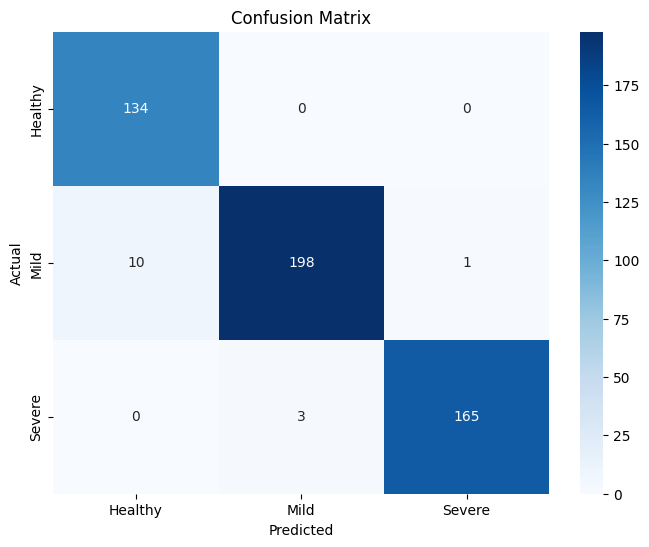

              precision    recall  f1-score   support

     Healthy       0.93      1.00      0.96       134
        Mild       0.99      0.95      0.97       209
      Severe       0.99      0.98      0.99       168

    accuracy                           0.97       511
   macro avg       0.97      0.98      0.97       511
weighted avg       0.97      0.97      0.97       511



In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
val_generator.reset()
predictions = model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
class_names = ['Healthy', 'Mild', 'Severe']

# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed report
print(classification_report(true_classes, predicted_classes, target_names=class_names))